In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.weibull_fit_params import WeibullFitParams

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.quick_calculate_Weibull import WeibullFittingFunction
from boulder_statistics.analysis.sensitivity_model import SensitivityModel

fit = WeibullFittingFunction(dp, LAD_min=0, sensitivity_model = SensitivityModel(dp.db_jaccard_agg))

In [3]:
from statsmodels.base.model import GenericLikelihoodModelResults

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = WeibullFitParams(lambda_ = 0.0002, k = 0.2053),
    verbose = False,
    summary=True
)

Optimization terminated successfully.
         Current function value: 6.162542
         Iterations: 62
         Function evaluations: 113
                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -2.6160e+06
Model:                      TheoryFit   AIC:                         5.232e+06
Method:            Maximum Likelihood   BIC:                         5.232e+06
Date:                Tue, 30 Jun 2026                                         
Time:                        11:37:11                                         
No. Observations:              424494                                         
Df Residuals:                  424492                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

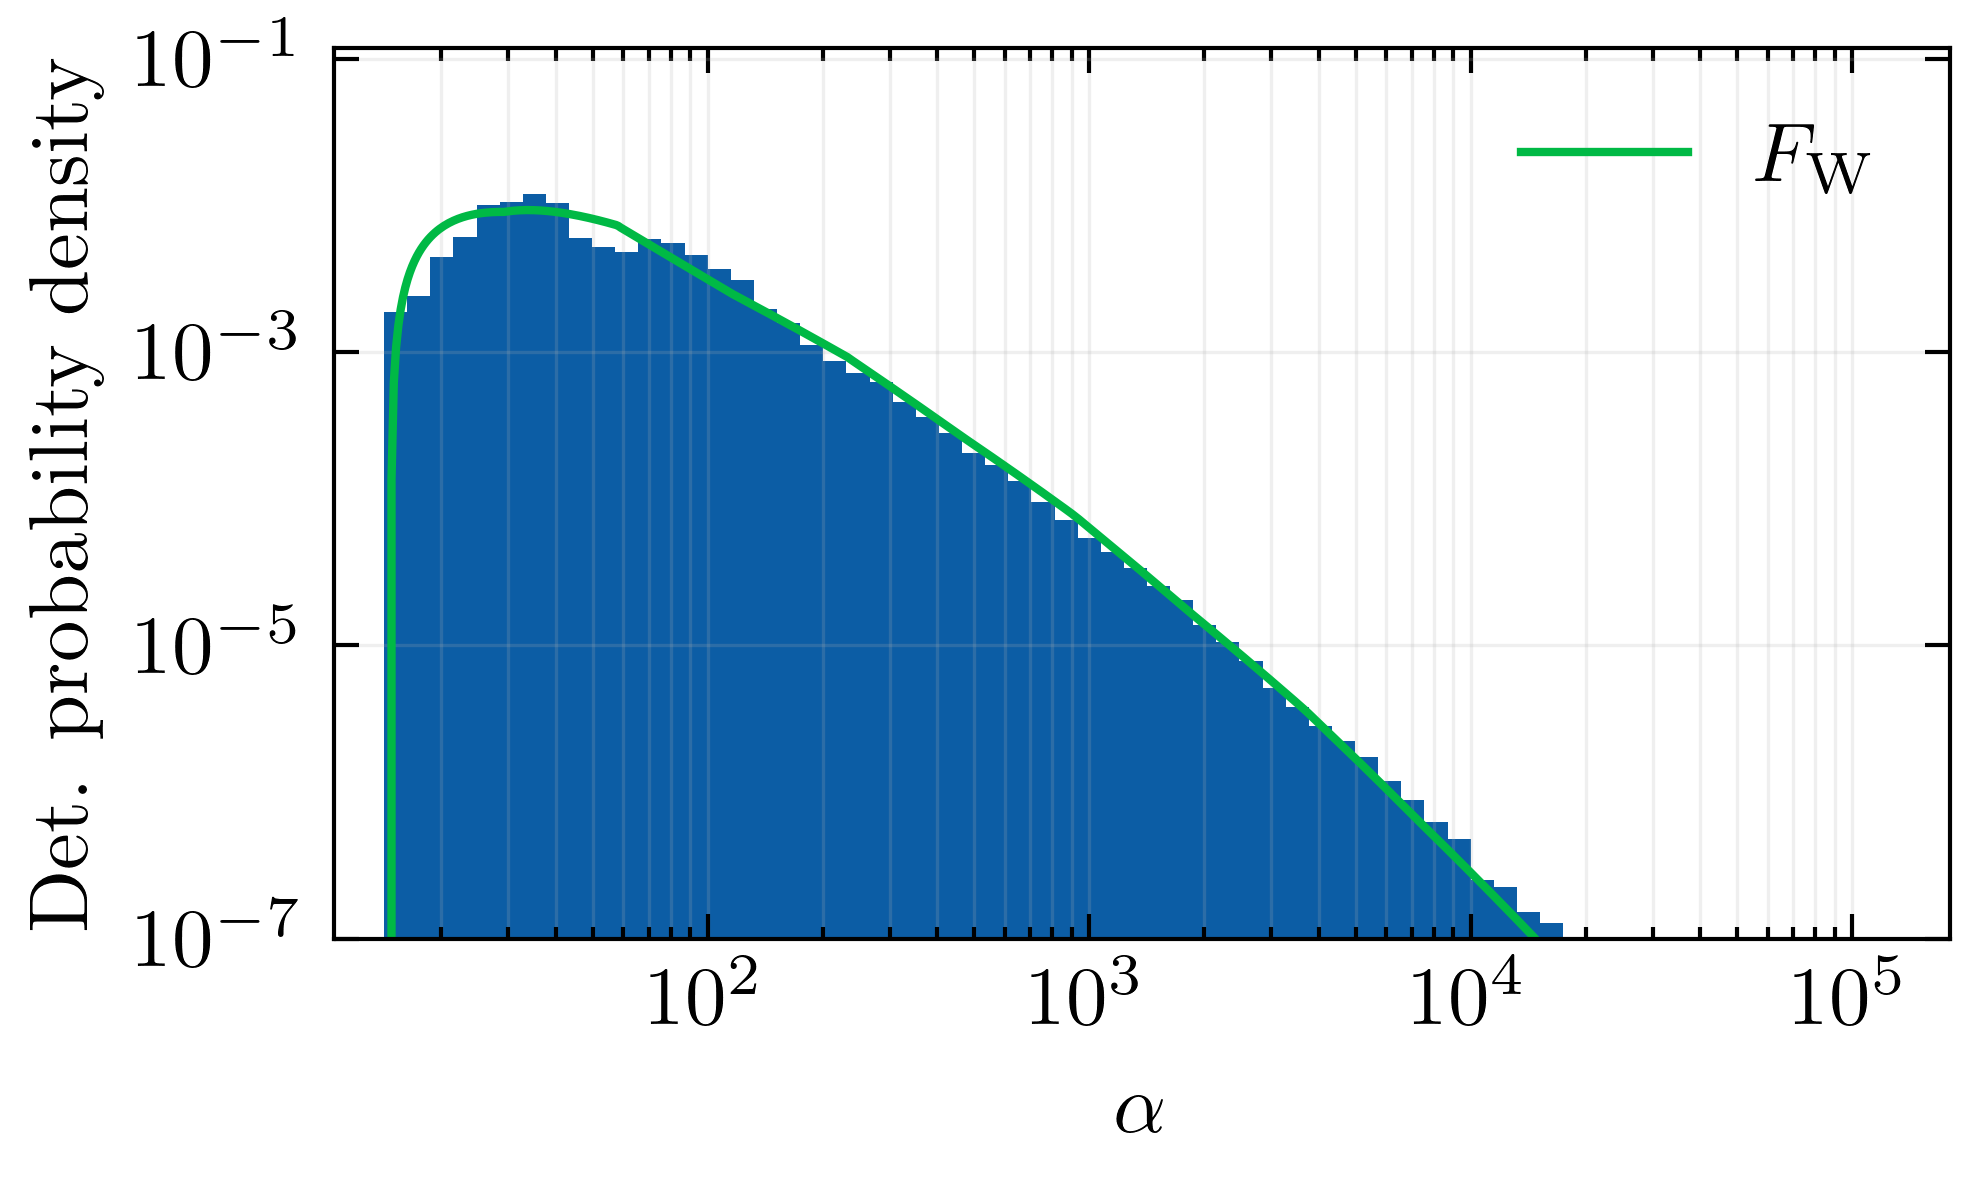

In [4]:
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True)

fit_params = WeibullFitParams(*mle_model.params)
# fit_params = WeibullFitParams(lambda_ = 0.0002, k = 0.2053)
plt.plot(alphas, fit.F_norm(alphas, fit_params, s_model=SensitivityModel(dp.db_jaccard_agg).best_p_function), label = r"$F_{\text{W}}$")

plt.ylim(1e-7, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/Weibull")

while True:
    df = fit.MultiMLEFit(
        optimize_params=WeibullFitParams(
            lambda_=0.0002,
            k=0.2053,
        ),
        summary = False,
        numb_runs=20,
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running:   0%|          | 0/20 [00:00<?, ?it/s]

Optimization terminated successfully.
         Current function value: 6.162712
         Iterations: 32
         Function evaluations: 62


MultiMLE fit running:   5%|▌         | 1/20 [00:15<04:49, 15.25s/it]

Optimization terminated successfully.
         Current function value: 6.158642
         Iterations: 24
         Function evaluations: 48


MultiMLE fit running:  10%|█         | 2/20 [00:28<04:10, 13.94s/it]

...

MultiMLE fit running:  60%|██████    | 12/20 [06:12<03:42, 27.76s/it]

Optimization terminated successfully.
         Current function value: 6.161530
         Iterations: 70
         Function evaluations: 135


C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_Weibull.py:29: RuntimeWarning: invalid value encountered in power
  -(
c:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
MultiMLE fit running:  65%|██████▌   | 13/20 [06:43<03:20, 28.71s/it]

Optimization terminated successfully.
         Current function value: 6.193737
         Iterations: 222
         Function evaluations: 413


c:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
MultiMLE fit running:  70%|███████   | 14/20 [07:59<04:18, 43.05s/it]

In [ ]:
bin_centers = 0.5 * (dp.Phi_counts_smoothed_bins[:-1] + dp.Phi_counts_smoothed_bins[1:])
bin_widths = np.abs(dp.Phi_counts_smoothed_bins[:-1] - dp.Phi_counts_smoothed_bins[1:])
mask = (dp.Phi_counts_smoothed_counts / bin_widths > 10**3) & (dp.Phi_counts_smoothed_counts * bin_widths > 10**3)
plt.plot(bin_centers[mask], dp.Phi_counts_smoothed_counts[mask], label = "Mesh (smoothed)")

bin_centers = 0.5 * (dp.Phi_counts_sphere_noisy_bins[:-1] + dp.Phi_counts_sphere_noisy_bins[1:])
mask = dp.Phi_counts_sphere_noisy_counts != 0
plt.plot(bin_centers[mask], dp.Phi_counts_sphere_noisy_counts[mask], label = "sphere (noisy)")

bin_centers = 0.5 * (dp.Phi_counts_sphere_theory_bins[:-1] + dp.Phi_counts_sphere_theory_bins[1:])
mask = dp.Phi_counts_sphere_theory_counts != 0
plt.plot(bin_centers[mask], dp.Phi_counts_sphere_theory_counts[mask], label = "sphere (theory)")

plt.xscale("log")
plt.yscale("log")
plt.legend()